In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import colormaps
list(colormaps)
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")
dg = pd.read_csv("test.csv")

In [3]:
df.head(20)

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
5,5,29.0,Male,45963.0,Married,1.0,Bachelor's,NaN,33.053198,Urban,...,2.0,4.0,614.0,5.0,2022-05-20 15:21:39.207847,Average,No,Weekly,House,3202.0
6,6,41.0,Male,40336.0,Married,0.0,PhD,NaN,NaN,Rural,...,2.0,8.0,807.0,6.0,2020-02-21 15:21:39.219432,Poor,No,Weekly,House,439.0
7,7,48.0,Female,127237.0,Divorced,2.0,High School,Employed,5.769783,Suburban,...,1.0,11.0,398.0,5.0,2022-08-08 15:21:39.181605,Average,No,Rarely,Condo,111.0
8,8,21.0,Male,1733.0,Divorced,3.0,Bachelor's,NaN,17.869551,Urban,...,1.0,10.0,685.0,8.0,2020-12-14 15:21:39.198406,Average,No,Monthly,Condo,213.0
9,9,44.0,Male,52447.0,Married,2.0,Master's,Employed,20.473718,Urban,...,1.0,9.0,635.0,3.0,2020-08-02 15:21:39.144722,Poor,No,Daily,Condo,64.0


In [4]:
df.tail()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
1199995,1199995,36.0,Female,27316.0,Married,0.0,Master's,Unemployed,13.772907,Urban,...,NaN,5.0,372.0,3.0,2023-05-03 15:21:39.257696,Poor,No,Daily,Apartment,1303.0
1199996,1199996,54.0,Male,35786.0,Divorced,NaN,Master's,Self-Employed,11.483482,Rural,...,NaN,10.0,597.0,4.0,2022-09-10 15:21:39.134960,Poor,No,Weekly,Apartment,821.0
1199997,1199997,19.0,Male,51884.0,Divorced,0.0,Master's,NaN,14.724469,Suburban,...,0.0,19.0,NaN,6.0,2021-05-25 15:21:39.106582,Good,No,Monthly,Condo,371.0
1199998,1199998,55.0,Male,NaN,Single,1.0,PhD,NaN,18.547381,Suburban,...,1.0,7.0,407.0,4.0,2021-09-19 15:21:39.190215,Poor,No,Daily,Apartment,596.0
1199999,1199999,21.0,Female,NaN,Divorced,0.0,PhD,NaN,10.125323,Rural,...,0.0,18.0,502.0,6.0,2020-08-26 15:21:39.155231,Good,Yes,Monthly,House,2480.0


In [5]:
df.columns = [col.replace(' ', '_').lower() for col in df.columns]
dg.columns = [col.replace(' ', '_').lower() for col in dg.columns]

In [6]:
df.nunique()

id                      1200000
age                          47
gender                        2
annual_income             88593
marital_status                3
number_of_dependents          5
education_level               4
occupation                    3
health_score             532657
location                      3
policy_type                   3
previous_claims              10
vehicle_age                  20
credit_score                550
insurance_duration            9
policy_start_date        167381
customer_feedback             3
smoking_status                2
exercise_frequency            4
property_type                 3
premium_amount             4794
dtype: int64

In [7]:
df.isna().sum()

id                           0
age                      18705
gender                       0
annual_income            44949
marital_status           18529
number_of_dependents    109672
education_level              0
occupation              358075
health_score             74076
location                     0
policy_type                  0
previous_claims         364029
vehicle_age                  6
credit_score            137882
insurance_duration           1
policy_start_date            0
customer_feedback        77824
smoking_status               0
exercise_frequency           0
property_type                0
premium_amount               0
dtype: int64

In [8]:
df.isna().mean().sort_values(ascending=False)

previous_claims         3.033575e-01
occupation              2.983958e-01
credit_score            1.149017e-01
number_of_dependents    9.139333e-02
customer_feedback       6.485333e-02
health_score            6.173000e-02
annual_income           3.745750e-02
age                     1.558750e-02
marital_status          1.544083e-02
vehicle_age             5.000000e-06
insurance_duration      8.333333e-07
gender                  0.000000e+00
id                      0.000000e+00
location                0.000000e+00
policy_type             0.000000e+00
education_level         0.000000e+00
policy_start_date       0.000000e+00
smoking_status          0.000000e+00
exercise_frequency      0.000000e+00
property_type           0.000000e+00
premium_amount          0.000000e+00
dtype: float64

In [9]:
df["previous_claims"] = df.groupby("property_type")["previous_claims"].transform(
    lambda x: x.fillna(x.median())
)
dg["previous_claims"] = dg.groupby("property_type")["previous_claims"].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
df["occupation"] = df["occupation"].fillna(df.groupby("education_level")["occupation"].transform(
    lambda x: x.mode().iloc[0])
)
dg["occupation"] = dg["occupation"].fillna(dg.groupby("education_level")["occupation"].transform(
    lambda x: x.mode().iloc[0])
)

In [11]:
df["credit_score"] = (df["credit_score"].fillna(df.groupby(["customer_feedback" , "insurance_duration"])["credit_score"].transform("median")))
dg["credit_score"] = (dg["credit_score"].fillna(dg.groupby(["customer_feedback" , "insurance_duration"])["credit_score"].transform("median")))

In [12]:
df["number_of_dependents"] = (df["number_of_dependents"].fillna(df.groupby(["marital_status" , "gender" , "age"])
    ["number_of_dependents"].transform("median")))
dg["number_of_dependents"] = (df["number_of_dependents"].fillna(df.groupby(["marital_status" , "gender" , "age"])
    ["number_of_dependents"].transform("median")))

In [13]:
df["customer_feedback"] = df["customer_feedback"].fillna(df.groupby(["credit_score" , "insurance_duration" , "policy_type"])["customer_feedback"].transform(
    lambda x: x.mode().iloc[0])
)
dg["customer_feedback"] = dg["customer_feedback"].fillna(dg.groupby(["credit_score" , "insurance_duration" , "policy_type"])["customer_feedback"].transform(
    lambda x: x.mode().iloc[0])
)

In [14]:
df["health_score"] = (df["health_score"].fillna(df.groupby(["smoking_status", "exercise_frequency" , "gender" , "age"])
    ["health_score"].transform("median")))
dg["health_score"] = (df["health_score"].fillna(dg.groupby(["smoking_status", "exercise_frequency" , "gender" , "age"])
    ["health_score"].transform("median")))

In [15]:
cf = df[df.notna().all(axis=1)]
cg = dg[dg.notna().all(axis=1)]

In [16]:
cf.nunique()
cg.nunique()

id                      738595
age                         47
gender                       2
annual_income            79657
marital_status               3
number_of_dependents         5
education_level              4
occupation                   3
health_score            365777
location                     3
policy_type                  3
previous_claims             10
vehicle_age                 20
credit_score               550
insurance_duration           9
policy_start_date       156452
customer_feedback            3
smoking_status               2
exercise_frequency           4
property_type                3
dtype: int64

In [17]:
cf.isna().sum()
cg.isna().sum()

id                      0
age                     0
gender                  0
annual_income           0
marital_status          0
number_of_dependents    0
education_level         0
occupation              0
health_score            0
location                0
policy_type             0
previous_claims         0
vehicle_age             0
credit_score            0
insurance_duration      0
policy_start_date       0
customer_feedback       0
smoking_status          0
exercise_frequency      0
property_type           0
dtype: int64

In [18]:
duplicates = cf[cf.duplicated()]

In [19]:
len(duplicates)

0

In [20]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1110977 entries, 0 to 1199997
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1110977 non-null  int64  
 1   age                   1110977 non-null  float64
 2   gender                1110977 non-null  object 
 3   annual_income         1110977 non-null  float64
 4   marital_status        1110977 non-null  object 
 5   number_of_dependents  1110977 non-null  float64
 6   education_level       1110977 non-null  object 
 7   occupation            1110977 non-null  object 
 8   health_score          1110977 non-null  float64
 9   location              1110977 non-null  object 
 10  policy_type           1110977 non-null  object 
 11  previous_claims       1110977 non-null  float64
 12  vehicle_age           1110977 non-null  float64
 13  credit_score          1110977 non-null  float64
 14  insurance_duration    1110977 non-null 

In [21]:
cf.head(10)

,id,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,...,previous_claims,vehicle_age,credit_score,insurance_duration,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type,premium_amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,Self-Employed,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,594.0,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,Employed,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
5,5,29.0,Male,45963.0,Married,1.0,Bachelor's,Employed,33.053198,Urban,...,2.0,4.0,614.0,5.0,2022-05-20 15:21:39.207847,Average,No,Weekly,House,3202.0
6,6,41.0,Male,40336.0,Married,0.0,PhD,Self-Employed,24.703651,Rural,...,2.0,8.0,807.0,6.0,2020-02-21 15:21:39.219432,Poor,No,Weekly,House,439.0
7,7,48.0,Female,127237.0,Divorced,2.0,High School,Employed,5.769783,Suburban,...,1.0,11.0,398.0,5.0,2022-08-08 15:21:39.181605,Average,No,Rarely,Condo,111.0
8,8,21.0,Male,1733.0,Divorced,3.0,Bachelor's,Employed,17.869551,Urban,...,1.0,10.0,685.0,8.0,2020-12-14 15:21:39.198406,Average,No,Monthly,Condo,213.0
9,9,44.0,Male,52447.0,Married,2.0,Master's,Employed,20.473718,Urban,...,1.0,9.0,635.0,3.0,2020-08-02 15:21:39.144722,Poor,No,Daily,Condo,64.0


(array([220060., 217924., 223006., 223190., 226797.]),
 array([ 0. ,  3.8,  7.6, 11.4, 15.2, 19. ]),
 <BarContainer object of 5 artists>)

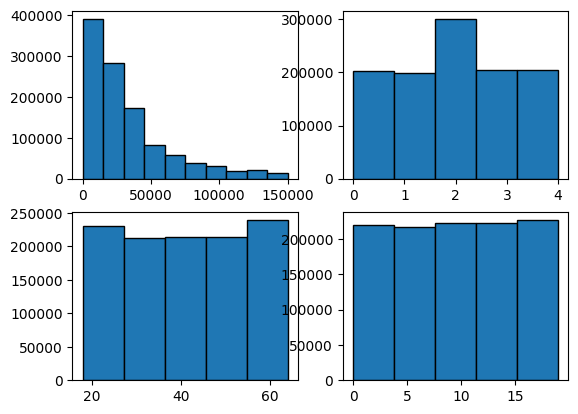

In [22]:
fig , ax = plt.subplots(2,2)
ax[0][0].hist(cf['annual_income'], edgecolor = "black" , bins = 10)
ax[0][1].hist(cf['number_of_dependents'], edgecolor = "black" , bins = 5)
ax[1][0].hist(cf['age'], edgecolor = "black" , bins = 5)
ax[1][1].hist(cf['vehicle_age'], edgecolor = "black" , bins = 5)

(array([632783., 304703., 128419.,  37829.,   7243.]),
 array([  20. , 1015.8, 2011.6, 3007.4, 4003.2, 4999. ]),
 <BarContainer object of 5 artists>)

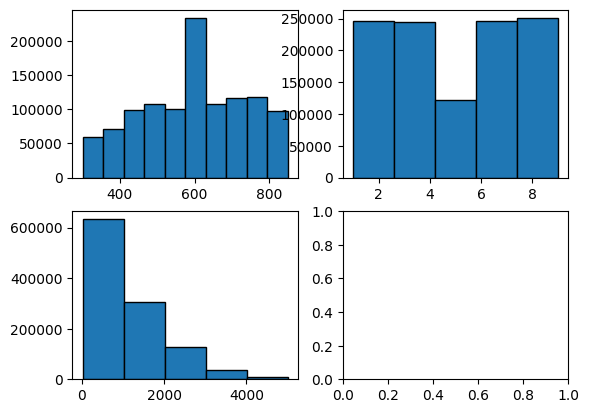

In [23]:
fig , ax = plt.subplots(2,2)
ax[0][0].hist(cf['credit_score'], edgecolor = "black" , bins = 10)
ax[0][1].hist(cf['insurance_duration'], edgecolor = "black" , bins = 5)
ax[1][0].hist(cf['premium_amount'], edgecolor = "black" , bins = 5)

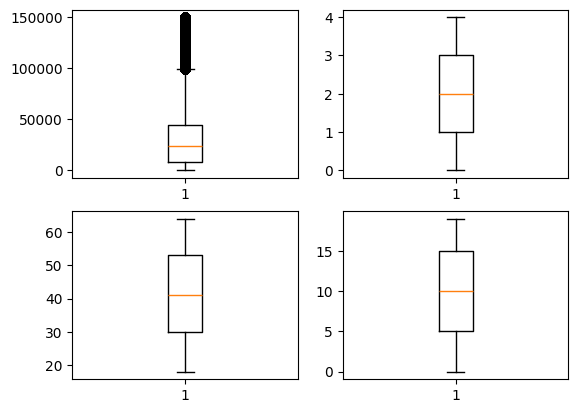

In [24]:
fig, ax = plt.subplots(2,2)
ax[0][0].boxplot(cf['annual_income'] , showfliers = True);
ax[0][1].boxplot(cf['number_of_dependents'] , showfliers = True);
ax[1][0].boxplot(cf['age'] , showfliers = True);
ax[1][1].boxplot(cf['vehicle_age'] , showfliers = True);

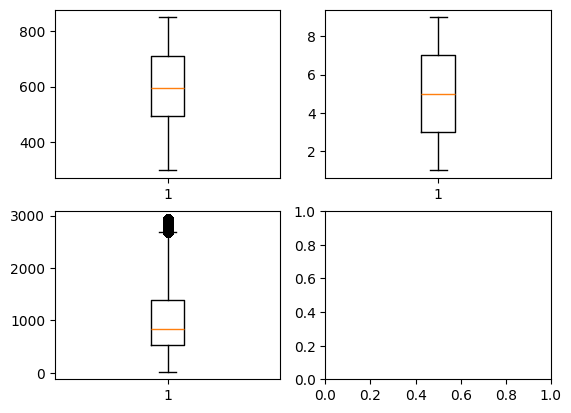

In [30]:
fig, ax = plt.subplots(2,2)
ax[0][0].boxplot(cf['credit_score'] , showfliers = True);
ax[0][1].boxplot(cf['insurance_duration'] , showfliers = True);
ax[1][0].boxplot(cf['premium_amount'] , showfliers = True);

In [26]:
Q1 = cf.annual_income.quantile(0.25)
Q2 = cf.annual_income.quantile(0.50)
Q3 = cf.annual_income.quantile(0.75)
IQR = Q3 - Q1
LC = Q1 - (1.5*IQR)
UC = Q3 + (1.5*IQR)
display(LC)
display(UC)

np.float64(-46410.5)

np.float64(98825.5)

In [27]:
cf = cf[(cf['annual_income'] >= LC) & (cf['annual_income'] <= UC)].reset_index(drop=True)
cg = cg[(cg['annual_income'] >= LC) & (cg['annual_income'] <= UC)].reset_index(drop=True)

In [28]:
q1 = cf.premium_amount.quantile(0.25)
q2 = cf.premium_amount.quantile(0.50)
q3 = cf.premium_amount.quantile(0.75)
iqr = q3 - q1
lc = q1 - (1.5*iqr)
uc = q3 + (1.5*iqr)
display(lc)
display(uc)

np.float64(-905.5)

np.float64(2938.5)

In [29]:
cf = cf[(cf['premium_amount'] >= lc) & (cf['premium_amount'] <= uc)].reset_index(drop=True)

In [78]:
cf.head(10)

,id,age,gender,annual_income,marital_status,number_of_dependents,education_level,occupation,health_score,location,...,previous_claims,vehicle_age,credit_score,insurance_duration,policy_start_date,customer_feedback,smoking_status,exercise_frequency,property_type,premium_amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,Self-Employed,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,594.0,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
4,6,41.0,Male,40336.0,Married,0.0,PhD,Self-Employed,24.703651,Rural,...,2.0,8.0,807.0,6.0,2020-02-21 15:21:39.219432,Poor,No,Weekly,House,439.0
5,8,21.0,Male,1733.0,Divorced,3.0,Bachelor's,Employed,17.869551,Urban,...,1.0,10.0,685.0,8.0,2020-12-14 15:21:39.198406,Average,No,Monthly,Condo,213.0
6,9,44.0,Male,52447.0,Married,2.0,Master's,Employed,20.473718,Urban,...,1.0,9.0,635.0,3.0,2020-08-02 15:21:39.144722,Poor,No,Daily,Condo,64.0
7,10,56.0,Female,8054.0,Married,1.0,Bachelor's,Unemployed,24.793447,Rural,...,1.0,8.0,431.0,8.0,2021-05-12 15:21:39.134960,Average,No,Monthly,Condo,857.0
8,11,23.0,Male,30983.0,Single,3.0,Master's,Self-Employed,5.813129,Urban,...,1.0,6.0,597.0,8.0,2020-03-22 15:21:39.155231,Good,No,Rarely,Condo,1447.0
9,12,25.0,Female,23706.0,Single,4.0,Master's,Employed,4.090538,Urban,...,2.0,19.0,599.0,2.0,2021-10-28 15:21:39.086123,Poor,Yes,Weekly,Apartment,703.0


In [79]:
cf["smoking_status"] = cf["smoking_status"].map({"Yes": 1, "No": 0})
cg["smoking_status"] = cg["smoking_status"].map({"Yes": 1, "No": 0})

In [80]:
cf = pd.get_dummies(
    cf,
    columns=["gender", "marital_status" , "occupation" , "location" , "property_type"],
    drop_first=False
)
cg = pd.get_dummies(
    cg,
    columns=["gender", "marital_status" , "occupation" , "location" , "property_type"],
    drop_first=False
)

In [81]:
education_level_map = {"High School": 1, "Bachelor's": 2, "Master's": 3 , "PhD" : 4}
cf["education_level"] = cf["education_level"].map(education_level_map)
cg["education_level"] = cg["education_level"].map(education_level_map)

In [82]:
policy_type_map = {"Basic": 1, "Comprehensive": 2, "Premium": 3}
cf["policy_type"] = cf["policy_type"].map(policy_type_map)
cg["policy_type"] = cg["policy_type"].map(policy_type_map)

In [83]:
customer_feedback_map = {"Poor": 1, "Average": 2, "Good": 3}
cf["customer_feedback"] = cf["customer_feedback"].map(customer_feedback_map)
cg["customer_feedback"] = cg["customer_feedback"].map(customer_feedback_map)

In [84]:
exercise_frequency_map = {"Rarely": 1, "Monthly": 2, "Weekly": 3 , "Daily" : 4}
cf["exercise_frequency"] = cf["exercise_frequency"].map(exercise_frequency_map)
cg["exercise_frequency"] = cg["exercise_frequency"].map(exercise_frequency_map)

In [85]:
cf.isna().sum()
cg.isna().sum()

id                          0
age                         0
annual_income               0
number_of_dependents        0
education_level             0
health_score                0
policy_type                 0
previous_claims             0
vehicle_age                 0
credit_score                0
insurance_duration          0
policy_start_date           0
customer_feedback           0
smoking_status              0
exercise_frequency          0
gender_Female               0
gender_Male                 0
marital_status_Divorced     0
marital_status_Married      0
marital_status_Single       0
occupation_Employed         0
occupation_Self-Employed    0
occupation_Unemployed       0
location_Rural              0
location_Suburban           0
location_Urban              0
property_type_Apartment     0
property_type_Condo         0
property_type_House         0
dtype: int64

In [86]:
cf.head(10)

,id,age,annual_income,number_of_dependents,education_level,health_score,policy_type,previous_claims,vehicle_age,credit_score,...,marital_status_Single,occupation_Employed,occupation_Self-Employed,occupation_Unemployed,location_Rural,location_Suburban,location_Urban,property_type_Apartment,property_type_Condo,property_type_House
0,0,19.0,10049.0,1.0,2,22.598761,3,2.0,17.0,372.0,...,False,False,True,False,False,False,True,False,False,True
1,1,39.0,31678.0,3.0,3,15.569731,2,1.0,12.0,694.0,...,False,False,True,False,True,False,False,False,False,True
2,2,23.0,25602.0,3.0,1,47.177549,3,1.0,14.0,594.0,...,False,False,True,False,False,True,False,False,False,True
3,4,21.0,39651.0,1.0,2,20.376094,3,0.0,8.0,598.0,...,True,False,True,False,True,False,False,False,False,True
4,6,41.0,40336.0,0.0,4,24.703651,1,2.0,8.0,807.0,...,False,False,True,False,True,False,False,False,False,True
5,8,21.0,1733.0,3.0,2,17.869551,3,1.0,10.0,685.0,...,False,True,False,False,False,False,True,False,True,False
6,9,44.0,52447.0,2.0,3,20.473718,2,1.0,9.0,635.0,...,False,True,False,False,False,False,True,False,True,False
7,10,56.0,8054.0,1.0,2,24.793447,3,1.0,8.0,431.0,...,False,False,False,True,True,False,False,False,True,False
8,11,23.0,30983.0,3.0,3,5.813129,3,1.0,6.0,597.0,...,True,False,True,False,False,False,True,False,True,False
9,12,25.0,23706.0,4.0,3,4.090538,2,2.0,19.0,599.0,...,True,True,False,False,False,False,True,True,False,False


In [99]:
cf.astype({'gender_female': 'int' , 'gender_male': 'int' , 'marital_status_divorced': 'int' ,
           'marital_status_single': 'int' , 'occupation_employed': 'int' , 'occupation_unemployed': 'int' , 
          'occupation_self-employed': 'int' , 'location_rural': 'int' , 'location_suburban': 'int' , 
          'location_urban': 'int' , 'marital_status_married' : 'int', 'property_type_apartment' : 'int' ,
           'property_type_condo' : 'int' , 'property_type_house': 'int'}).dtypes

id                            int64
age                         float64
annual_income               float64
number_of_dependents        float64
education_level               int64
health_score                float64
policy_type                   int64
previous_claims             float64
vehicle_age                 float64
credit_score                float64
insurance_duration          float64
policy_start_date            object
customer_feedback             int64
smoking_status                int64
exercise_frequency            int64
premium_amount              float64
gender_female                 int64
gender_male                   int64
marital_status_divorced       int64
marital_status_married        int64
marital_status_single         int64
occupation_employed           int64
occupation_self-employed      int64
occupation_unemployed         int64
location_rural                int64
location_suburban             int64
location_urban                int64
property_type_apartment     

In [100]:
cf.columns = [col.lower() for col in cf.columns]
print(cf.columns)

Index(['id', 'age', 'annual_income', 'number_of_dependents', 'education_level',
       'health_score', 'policy_type', 'previous_claims', 'vehicle_age',
       'credit_score', 'insurance_duration', 'policy_start_date',
       'customer_feedback', 'smoking_status', 'exercise_frequency',
       'premium_amount', 'gender_female', 'gender_male',
       'marital_status_divorced', 'marital_status_married',
       'marital_status_single', 'occupation_employed',
       'occupation_self-employed', 'occupation_unemployed', 'location_rural',
       'location_suburban', 'location_urban', 'property_type_apartment',
       'property_type_condo', 'property_type_house'],
      dtype='object')


In [101]:
# X_train = cf.drop(["premium_amount", "id", "policy_start_date"], axis=1)
# y_train = cf["premium_amount"]

# X_test = cg.drop(["id", "policy_start_date"], axis=1)
X = cf.drop(["premium_amount", "id", "policy_start_date"], axis=1)
y = cf["premium_amount"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("training set:", X_train.shape, y_train.shape)
print("testing set:", X_test.shape, y_test.shape)

training set: (801217, 27) (801217,)
testing set: (200305, 27) (200305,)


In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [103]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [104]:
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
y_pred = model.predict(X_test_scaled)

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Mean Absolute Error: 547.4704771291925
Mean Squared Error: 684.5878587549232
R-squared Score: 0.005640539887953766


In [107]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs = -1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(r2_score(y_test, y_pred))

0.027339785516943604
